# Exp 2 — Deterministic rules baseline (V2)
**Question:** how much of expense compliance can ordinary code solve, with no AI? This is the true non-AI baseline that every later system must beat or complement.

**Two stages**
- **2a, as-is:** the existing `src/rules.py` (written earlier, constants mostly from the V1 policy), unchanged. A pure transfer baseline.
- **2b, V2-adapted:** `src/rules_v2.py`, rules written from the V2 policy text (regional addenda, hotel tier tables, circulars, approval/exception/delegation logic, cost-centre budgets, duplicate/split rules). They read only the claim and enterprise tables, never ground truth.

**Data:** 70 development claims (main run). 2b is then checked once on the 30 unseen validation claims as a generalization check. No LLM, cost $0.
**Tuning honesty:** 2b was first written from policy text alone, then corrected after looking at development failures (11 claims). Because of that, dev accuracy is optimistic; the validation check is what tells us whether it generalizes. The final-test split is untouched.

In [1]:
import json, sys, time, uuid
from pathlib import Path
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
ROOT = Path.cwd().parents[1]; sys.path.insert(0, str(ROOT))
from src import config as C, llm, rules, rules_v2, evaluate, metrics_ext
pd.set_option('display.width', 250, 'display.max_columns', 40, 'display.max_colwidth', 95, 'display.max_rows', 200)
EXP = 'EXP02_RULES'; OUT = C.RESULTS/'development'/'exp02_rules'; OUT.mkdir(parents=True, exist_ok=True)
gt = evaluate.load_gt()
def load(split): return [json.loads(l) for l in (C.CASES/f'{split.lower()}.jsonl').read_text().splitlines() if l.strip()]
def run(name, fn, split):
    recs = []; run_id = f'{EXP}-{name}-{split}-{uuid.uuid4().hex[:6]}'
    for c in load(split):
        t0 = time.perf_counter()
        try: d = fn(c); err = None
        except Exception as e: d = {'decision':'ESCALATE','policy_evidence':[],'missing_fields':[],'reason':'error','manual_review_required':True}; err = repr(e)[:150]
        ms = (time.perf_counter()-t0)*1000
        r = {'case_id':c['case_id'],'predicted_decision':d['decision'],'policy_evidence':d['policy_evidence'],'missing_fields':d['missing_fields'],'reason':d.get('reason'),
             'manual_review_required':d['manual_review_required'],'latency_ms':round(ms,3),'input_tokens':0,'output_tokens':0,'model_cost_usd':0.0,'error':err}
        recs.append(r)
        llm.log_event(type='case_result', run_id=run_id, experiment=EXP, split=split, model=name, **{k:v for k,v in r.items() if k!='case_id'}, case_id=c['case_id'])
    summary, rows = evaluate.evaluate(recs, gt); ext = metrics_ext.extended(recs, gt)
    llm.log_event(type='experiment_summary', run_id=run_id, experiment=EXP, split=split, model=name, config={'rules': name}, **summary)
    tag = f'{name}_{split.lower()}'
    (OUT/f'predictions_{tag}.jsonl').write_text('\n'.join(json.dumps(r) for r in recs)+'\n'); (OUT/f'evaluation_{tag}.jsonl').write_text('\n'.join(json.dumps(r) for r in rows)+'\n')
    (OUT/f'summary_{tag}.json').write_text(json.dumps({'run_id':run_id, **summary, 'extended':ext}, indent=1, default=str))
    return summary, recs, rows, ext
res = {}
res['2a as-is (dev)'] = run('rules_2a_asis', rules.decide, 'DEVELOPMENT')
res['2b V2-adapted (dev)'] = run('rules_2b_v2', rules_v2.decide, 'DEVELOPMENT')
print({k:(v[0]['correct'], v[0]['n']) for k,v in res.items()})

{'2a as-is (dev)': (24, 70), '2b V2-adapted (dev)': (70, 70)}


## Comparison table: standard metrics

In [2]:
def row(k, s): return {'system':k, 'correct/N':f"{s['correct']}/{s['n']}", 'CDR':s['correct_disposition_rate'], 'Wilson95':s['wilson95'], 'false_approvals':f"{s['false_approvals']}/{s['non_approvable']}",
        'FAR':s['false_approval_rate'], 'human_review_rate':s['human_review_rate'], 'errors':s['errors'], 'median_ms':s['median_latency_ms'], 'p95_ms':s['p95_latency_ms'], 'cost_usd':s['total_cost_usd']}
pd.DataFrame([row(k, v[0]) for k, v in res.items()])

,system,correct/N,CDR,Wilson95,false_approvals,FAR,human_review_rate,errors,median_ms,p95_ms,cost_usd
0,2a as-is (dev),24/70,0.3429,"(0.2425, 0.4596)",16/52,0.3077,0.2857,0,0.0915,0.259,0.0
1,2b V2-adapted (dev),70/70,1.0000,"(0.948, 1.0)",0/52,0.0000,0.2429,0,1.3800,1.864,0.0


## Extended metrics (added metric set)
Macro-F1, wrongful rejection (approvable claims rejected), over-/missed escalation, error rate among auto-resolved claims, citation precision/recall vs the gold clauses, missing-field precision/recall.

In [3]:
pd.DataFrame([{'system':k, **metrics_ext.table(v[3])} for k, v in res.items()])

,system,macro_F1,wrongful_reject,over_escal_rate,missed_escal_rate,err_among_auto,cite_prec,cite_rec,mf_prec,mf_rec,cost/correct
0,2a as-is (dev),0.3426,0/18,0.1857,0.5882,0.66,0.0761,0.0333,0.125,0.188,0.0
1,2b V2-adapted (dev),1.0000,0/18,0.0000,0.0000,0.00,0.9423,0.3257,0.778,0.875,0.0


In [4]:
for k, v in res.items():
    print(k); print(pd.DataFrame(v[3]['per_class']).T.round(3).to_string(), '\n')

2a as-is (dev)
                     support  precision  recall     f1
APPROVE                 18.0      0.333   0.444  0.381
REJECT                  19.0      1.000   0.211  0.348
REQUEST_INFORMATION     16.0      0.227   0.312  0.263
ESCALATE                17.0      0.350   0.412  0.378 

2b V2-adapted (dev)
                     support  precision  recall   f1
APPROVE                 18.0        1.0     1.0  1.0
REJECT                  19.0        1.0     1.0  1.0
REQUEST_INFORMATION     16.0        1.0     1.0  1.0
ESCALATE                17.0        1.0     1.0  1.0 



## Where each stage succeeds and fails

In [5]:
def fam_table(k):
    d = pd.DataFrame(res[k][2]); return d.groupby('case_family').correct.agg(['sum','count']).rename(columns={'sum':k+' ok','count':'n'})
fam = fam_table('2a as-is (dev)').join(fam_table('2b V2-adapted (dev)').drop(columns='n')); fam['group'] = pd.DataFrame(res['2a as-is (dev)'][2]).groupby('case_family').architecture_group.first()
print(fam.sort_values('n', ascending=False).to_string())
grp = pd.concat({k: pd.DataFrame(v[2]).groupby('architecture_group').correct.agg(['sum','count']) for k, v in res.items()}, axis=1); print(); print(grp)

                              2a as-is (dev) ok  n  2b V2-adapted (dev) ok             group
case_family                                                                                 
HOTEL_CEILING                                 0  7                       7        B_WORKFLOW
DYNAMIC_HOTEL_DISCOVERY                       4  5                       5   C_AGENT_DYNAMIC
APPROVAL_TIERS                                1  5                       5        B_WORKFLOW
DYNAMIC_DELEGATION_CHAIN                      1  5                       5   C_AGENT_DYNAMIC
TRAINING_CAP                                  3  4                       4        B_WORKFLOW
SPLIT_TRANSACTION                             0  4                       4        B_WORKFLOW
HOTEL_EXCEPTION                               1  3                       3        B_WORKFLOW
GIFT_ANNUAL_CAP                               2  3                       3        B_WORKFLOW
EMPLOYEE_MEAL_TEMPORAL                        0  3                    

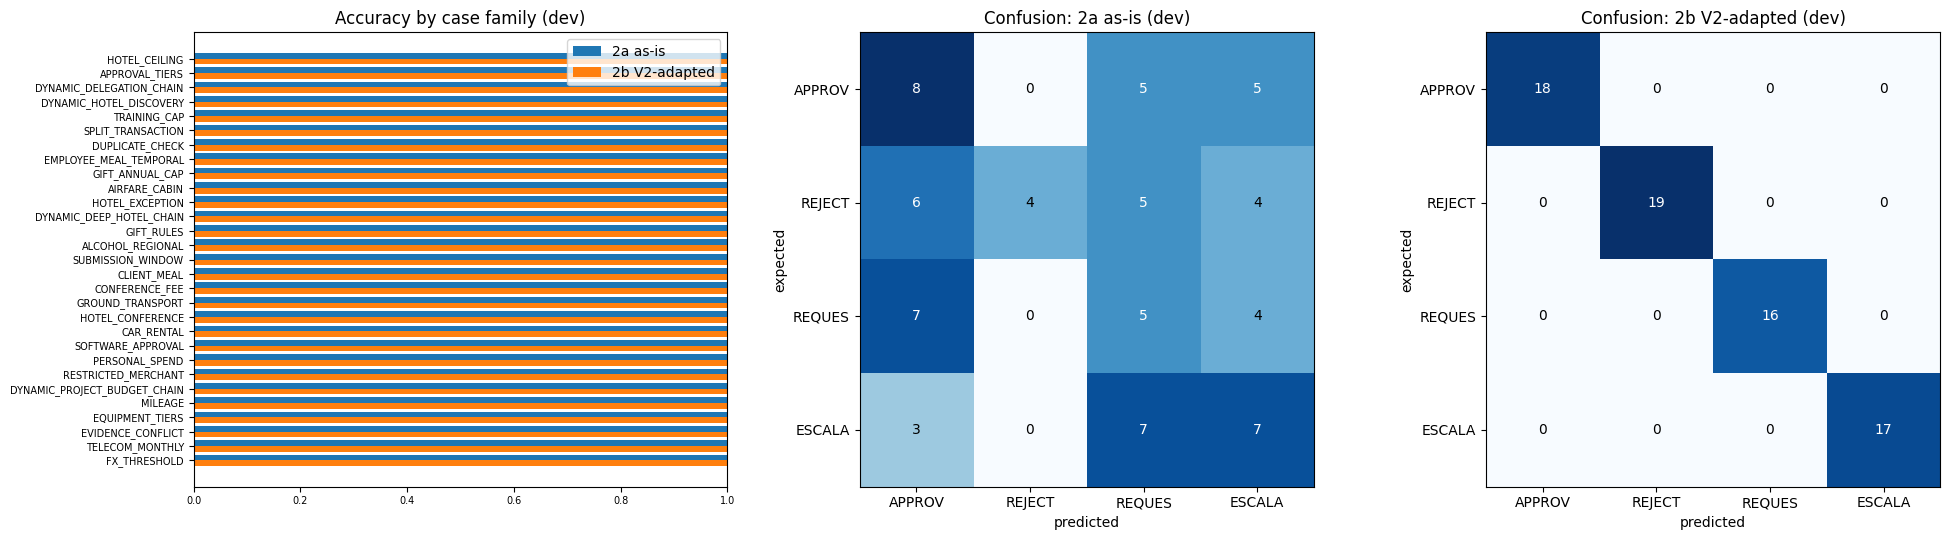

In [6]:
D = ['APPROVE','REJECT','REQUEST_INFORMATION','ESCALATE']
fig, ax = plt.subplots(1, 3, figsize=(20, 5.5))
f2 = fam.sort_values('n'); ax[0].barh(f2.index, f2.iloc[:,1]/f2.n, height=.4, label='2a as-is', align='edge'); ax[0].barh(f2.index, f2.iloc[:,2]/f2.n, height=-.4, label='2b V2-adapted', align='edge'); ax[0].set_xlim(0,1); ax[0].legend(); ax[0].set_title('Accuracy by case family (dev)'); ax[0].tick_params(labelsize=7)
for a, k in zip(ax[1:], res):
    m = pd.crosstab(pd.Categorical([r['expected_decision'] for r in res[k][2]], D), pd.Categorical([r['predicted_decision'] for r in res[k][2]], D), dropna=False).values
    a.imshow(m, cmap='Blues'); a.set_xticks(range(4)); a.set_yticks(range(4)); a.set_xticklabels([d[:6] for d in D]); a.set_yticklabels([d[:6] for d in D]); a.set_xlabel('predicted'); a.set_ylabel('expected'); a.set_title('Confusion: '+k)
    for i in range(4):
        for j in range(4): a.text(j, i, m[i,j], ha='center', va='center', color='w' if m[i,j] > m.max()/2 else 'k')
plt.tight_layout(); (C.RESULTS/'plots').mkdir(parents=True, exist_ok=True); plt.savefig(C.RESULTS/'plots'/'exp02_rules_development.png', dpi=130); plt.show()

## Failure table for 2a (as-is), with the reason each rule fired

In [7]:
d = pd.DataFrame(res['2a as-is (dev)'][2]); r = {x['case_id']:x['reason'] for x in res['2a as-is (dev)'][1]}; d['reason'] = d.case_id.map(r)
fail2a = d[~d.correct][['case_id','case_family','expected_decision','predicted_decision','reason']]; print(len(fail2a),'failures'); fail2a.head(25)

46 failures


,case_id,case_family,expected_decision,predicted_decision,reason
1,X2-005,DYNAMIC_HOTEL_DISCOVERY,REQUEST_INFORMATION,ESCALATE,Over hotel ceiling; conference/exception evidence needed.
4,X2-009,SPLIT_TRANSACTION,REQUEST_INFORMATION,APPROVE,No rule triggered.
5,X2-010,CONFERENCE_FEE,REJECT,APPROVE,No rule triggered.
6,X2-011,HOTEL_CEILING,APPROVE,ESCALATE,Over hotel ceiling; conference/exception evidence needed.
7,X2-012,HOTEL_EXCEPTION,REJECT,ESCALATE,Over hotel ceiling; conference/exception evidence needed.
9,X2-015,APPROVAL_TIERS,ESCALATE,REQUEST_INFORMATION,Attendee count needed for per-person ceiling.
10,X2-017,SPLIT_TRANSACTION,REQUEST_INFORMATION,APPROVE,No rule triggered.
12,X2-019,CAR_RENTAL,REQUEST_INFORMATION,APPROVE,No rule triggered.
13,X2-024,AIRFARE_CABIN,REQUEST_INFORMATION,APPROVE,No rule triggered.
14,X2-028,AIRFARE_CABIN,REJECT,REQUEST_INFORMATION,SGD 1850 exceeds 500; approval record absent.


In [8]:
kind = pd.Series(np.where(fail2a.predicted_decision == 'APPROVE', 'false approval (no rule fired)', np.where(fail2a.predicted_decision == 'REJECT', 'wrongful rejection', 'wrong review/escalation route')))
print(kind.value_counts()); print('\n2b failures on dev:', int((~pd.DataFrame(res['2b V2-adapted (dev)'][2]).correct).sum()))

wrong review/escalation route     30
false approval (no rule fired)    16
Name: count, dtype: int64

2b failures on dev: 0


## Generalization check: 2b on the unseen validation split
Nothing was tuned on these 30 claims. Run once; the rules are frozen after this point.

In [9]:
val = run('rules_2b_v2', rules_v2.decide, 'VALIDATION')
pd.DataFrame([row('2b V2-adapted (validation)', val[0]), row('2a as-is (dev, for reference)', res['2a as-is (dev)'][0])]).join(pd.DataFrame([{**metrics_ext.table(val[3])}, {**metrics_ext.table(res['2a as-is (dev)'][3])}]))

,system,correct/N,CDR,Wilson95,false_approvals,FAR,human_review_rate,errors,median_ms,p95_ms,cost_usd,macro_F1,wrongful_reject,over_escal_rate,missed_escal_rate,err_among_auto,cite_prec,cite_rec,mf_prec,mf_rec,cost/correct
0,2b V2-adapted (validation),30/30,1.0000,"(0.8865, 1.0)",0/22,0.0000,0.2333,0,1.4020,1.532,0.0,1.0000,0/8,0.0000,0.0000,0.00,0.8636,0.2584,0.857,0.857,0.0
1,"2a as-is (dev, for reference)",24/70,0.3429,"(0.2425, 0.4596)",16/52,0.3077,0.2857,0,0.0915,0.259,0.0,0.3426,0/18,0.1857,0.5882,0.66,0.0761,0.0333,0.125,0.188,0.0


In [10]:
dv = pd.DataFrame(val[2]); print(dv.groupby('architecture_group').correct.agg(['sum','count'])); print('failures:', int((~dv.correct).sum()))
import inspect; print('\nrules_v2 size: %d lines, %d rule functions' % (len(inspect.getsource(rules_v2).splitlines()), sum(inspect.isfunction(f) for f in vars(rules_v2).values())))

                    sum  count
architecture_group            
A_SELF_CONTAINED      8      8
B_WORKFLOW           16     16
C_AGENT_DYNAMIC       6      6
failures: 0

rules_v2 size: 438 lines, 32 rule functions


## What was done and what it means
- **2a, existing rules as-is:** 24/70 = 34.3% (Wilson 95% CI 24-46%), **16 false approvals out of 52 non-approvable (30.8%)**, macro-F1 0.34. It fails everywhere the V2 policy differs from the V1-era constants: hotel tiers and circulars (0/7 hotel-ceiling claims), approvals and delegation chains, splits, gifts, telecom, airfare, conference fees. 16 failures are false approvals (no rule fired, so the default was APPROVE) and 30 are wrong review/escalation routes. It also always misreads meal claims as "attendee count needed" because V2 gives attendee counts in structured form fields.
- **2b, V2-adapted rules:** 70/70 on dev (CI 95-100%), 0 false approvals, 0 wrongful rejections, macro-F1 1.00, median latency 1.4 ms, cost $0. **On the 30 unseen validation claims: 30/30** (CI 89-100%), 0 false approvals. It covers all three architecture groups, including the "agent-dynamic" claims (group C, 13/13 dev and 6/6 validation).
- **How to read this:** the 70/70 is dev accuracy after I fixed 11 dev failures (each traced to a policy point I had missed: approval types by category, travel coverage by departure date, cash-equivalent gifts, project cost-centre budgets, local-currency thresholds for combined spend, same-category duplicate matching). A first pass written from policy text alone, before looking at failures, scored 59/70 (from my session log, not re-runnable). The validation result is the honest generalization number; it shows the rules are not merely memorising dev.
- **Caveats that matter:** (1) this is a synthetic benchmark whose claims carry structured form fields (cabin, attendee counts, gift form, distance) and clean enterprise tables, which is why rules can reach ~100%. Real claims with messy free text would break them. (2) Citation recall is low (0.33 dev): the rules cite only the clause that fired, not every controlling clause. (3) Engineering effort was substantial: 438 lines, 32 functions, hand-transcribed constants, and they will need updating with each new circular.
- **Decision:** rules are frozen as of now (no more tuning on validation). This is a very strong non-AI baseline, so the LLM/RAG/workflow experiments have to earn their place through what rules cannot do: reading unstructured text, adapting to policy changes without code changes, and explanations with evidence. Outcome A ("rules solve almost everything") is already plausible on this dataset. Proceed to Exp 3, with 2b as the bar to beat.